# Random Forest (3/6) — Bagging vs Random Forest

### The idea in one sentence
> Bagging and random forest both train many trees on bootstrap samples. The difference is **where the random
> features are chosen**: bagging picks them **once per tree**, a random forest picks them **again at every split**.

### In this notebook
1. A small dataset with 5 features
2. **The key difference:** feature subset per tree (bagging) vs per split (random forest)
3. **Build a random forest by hand:** row sampling + column sampling + majority vote
4. Bagging vs random forest: accuracy and **diversity** of the trees

> 📖 Theory: [`theory.md`](theory.md) §2 and §10 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

## 1. The data

A synthetic dataset: 500 rows, 5 numeric features (`col1` … `col5`), all useful, and a 0/1 target.

In [2]:
X, y = make_classification(n_samples=500, n_features=5, n_informative=5, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)
cols = ['col1', 'col2', 'col3', 'col4', 'col5']
df = pd.DataFrame(X, columns=cols)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(df.shape, '| train:', X_train.shape, '| test:', X_test.shape)
df.head().round(3)

(500, 6) | train: (350, 5) | test: (150, 5)


,col1,col2,col3,col4,col5,target
0,1.539,0.389,1.060,-1.623,0.849,1
1,-2.091,1.421,-1.365,0.121,0.603,0
2,-0.436,4.071,-0.308,-1.686,3.600,1
3,1.705,-0.038,1.488,-0.966,0.761,1
4,-0.265,1.794,0.101,-0.547,2.838,1


## 2. The key difference: per tree vs per split

We give **both** models the same setting, `max_features=2`, but it means two different things:

| Model | What `max_features=2` means |
|---|---|
| `BaggingClassifier` | each **tree** gets 2 random columns and uses only those for its whole life |
| `RandomForestClassifier` | at **every split (node)** a fresh random pair of columns is drawn |

> ✍️ **Core code: learn this.** Same `max_features`, two different models.

In [3]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                        max_features=2, random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42).fit(X_train, y_train)

# Bagging stores the columns each tree was given:
for i in range(5):
    print(f"bagging tree {i} was given columns:", [cols[j] for j in bag.estimators_features_[i]])

bagging tree 0 was given columns: ['col5', 'col1']
bagging tree 1 was given columns: ['col1', 'col3']
bagging tree 2 was given columns: ['col3', 'col5']
bagging tree 3 was given columns: ['col4', 'col5']
bagging tree 4 was given columns: ['col5', 'col4']


Each bagging tree is stuck with its two columns. A random forest does not store a column list per tree,
because there is none: the choice happens inside the tree, node by node. Let us **count which columns each tree
actually used** in its splits.

> ✍️ **Core code: learn this.** `tree_.feature` lists the column used at every node (`-2` marks a leaf).

In [4]:
def columns_used(tree, feature_ids=None):
    f = tree.tree_.feature
    f = f[f >= 0]                       # drop leaves
    if feature_ids is not None:          # bagging trees see only their own columns: map back to the originals
        f = np.asarray(feature_ids)[f]
    return sorted({cols[j] for j in f})

for i in range(5):
    print(f"tree {i} | bagging uses {columns_used(bag.estimators_[i], bag.estimators_features_[i])}"
          f" | random forest uses {columns_used(rf.estimators_[i])}")

n_bag = [len(columns_used(t, f)) for t, f in zip(bag.estimators_, bag.estimators_features_)]
n_rf = [len(columns_used(t)) for t in rf.estimators_]
print("\nAverage number of different columns used per tree:")
print("  bagging      :", np.mean(n_bag))
print("  random forest:", np.mean(n_rf))

tree 0 | bagging uses ['col1', 'col5'] | random forest uses ['col1', 'col2', 'col3', 'col4', 'col5']
tree 1 | bagging uses ['col1', 'col3'] | random forest uses ['col1', 'col2', 'col3', 'col4', 'col5']
tree 2 | bagging uses ['col3', 'col5'] | random forest uses ['col1', 'col3', 'col4', 'col5']
tree 3 | bagging uses ['col4', 'col5'] | random forest uses ['col1', 'col2', 'col3', 'col4', 'col5']
tree 4 | bagging uses ['col4', 'col5'] | random forest uses ['col1', 'col2', 'col3', 'col4', 'col5']

Average number of different columns used per tree:
  bagging      : 2.0
  random forest: 4.86


Now look at the top of one tree from each model:

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

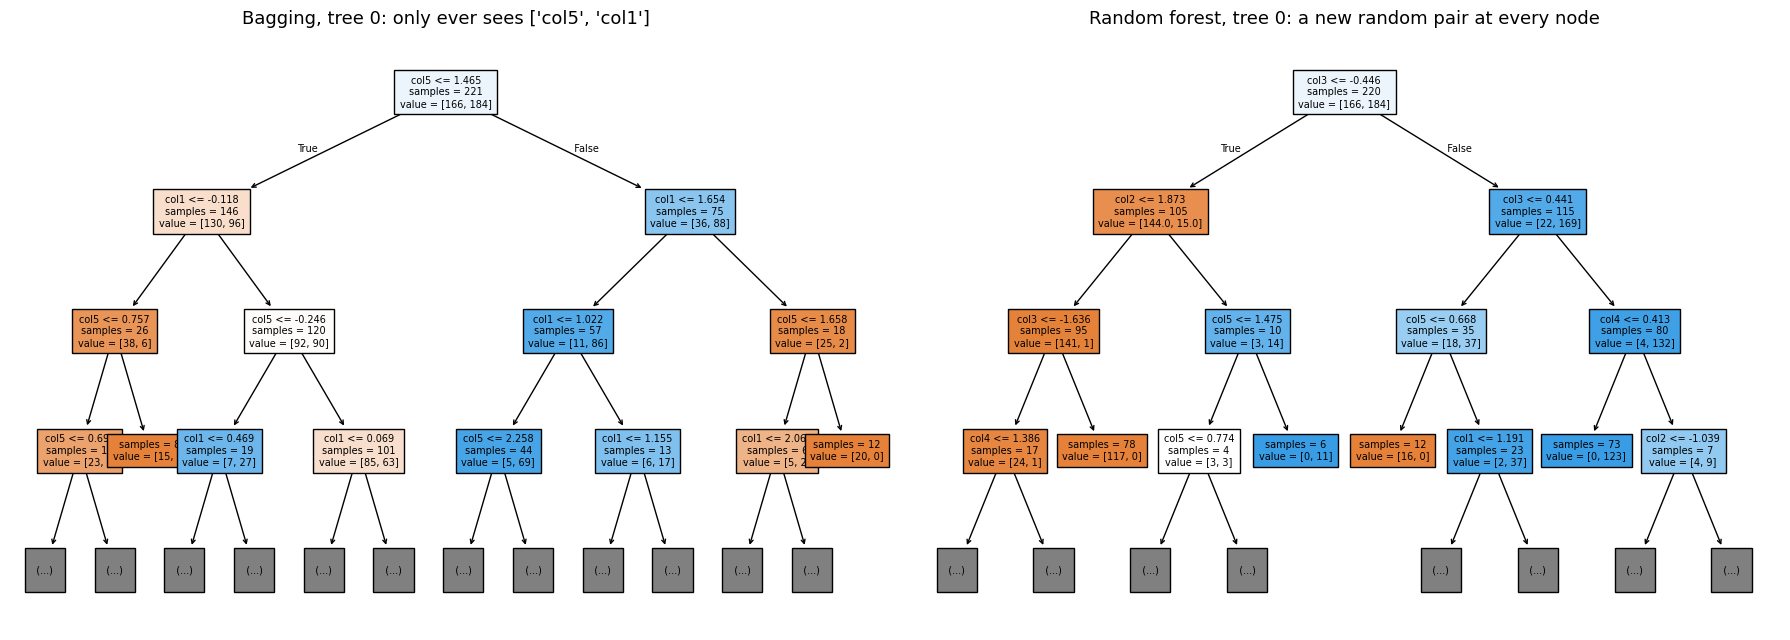

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
names0 = [cols[j] for j in bag.estimators_features_[0]]
plot_tree(bag.estimators_[0], max_depth=3, feature_names=names0, filled=True, impurity=False,
          fontsize=7, ax=axes[0])
axes[0].set_title(f"Bagging, tree 0: only ever sees {names0}", fontsize=13)
plot_tree(rf.estimators_[0], max_depth=3, feature_names=cols, filled=True, impurity=False,
          fontsize=7, ax=axes[1])
axes[1].set_title("Random forest, tree 0: a new random pair at every node", fontsize=13)
plt.tight_layout()
plt.show()

**Read the split rules (first line of every box):**
- The bagging tree only ever asks about its own two columns, at every depth.
- The random-forest tree asks about many different columns, because each node drew its own random pair.

So a random-forest tree can still **use every feature** somewhere, while it cannot rely on the single strongest
feature at every node. That makes the trees **more different from each other** without crippling any of them.

## 3. Build a random forest by hand

To *see* the recipe, we build a tiny forest ourselves with pandas:
1. **Row sampling:** draw rows at random *with replacement* (bootstrap).
2. **Column sampling:** keep a random subset of the feature columns.
3. Train one decision tree on each sampled table.
4. **Majority vote** of the trees.

> ⚠️ To keep it simple, our hand-made version picks the columns **once per tree** (like bagging with
> `max_features`). A real random forest re-draws them at every split (Section 2), which needs changes inside the
> tree algorithm itself.

> ✍️ **Core code: learn this.** The three sampling functions.

In [6]:
train_df = pd.DataFrame(X_train, columns=cols)
train_df['target'] = y_train

def sample_rows(df, percent, seed):
    # bootstrap: draw rows WITH replacement
    return df.sample(int(percent * len(df)), replace=True, random_state=seed)

def sample_features(df, percent, seed):
    # pick a random subset of the feature columns (always keep the target)
    rng = np.random.default_rng(seed)
    features = list(df.columns[:-1])
    chosen = sorted(rng.choice(features, int(percent * len(features)), replace=False))
    return df[chosen + ['target']]

def combined_sampling(df, row_percent, col_percent, seed):
    return sample_features(sample_rows(df, row_percent, seed), col_percent, seed)

df1 = combined_sampling(train_df, 1.0, 0.6, seed=1)
df2 = combined_sampling(train_df, 1.0, 0.6, seed=2)
df3 = combined_sampling(train_df, 1.0, 0.6, seed=3)
for name, d in [('df1', df1), ('df2', df2), ('df3', df3)]:
    print(f"{name}: columns {list(d.columns[:-1])}, {len(d)} rows, "
          f"{d.index.nunique()} distinct rows ({d.index.nunique() / len(d):.0%})")

df1: columns ['col2', 'col3', 'col4'], 350 rows, 228 distinct rows (65%)
df2: columns ['col1', 'col2', 'col3'], 350 rows, 228 distinct rows (65%)
df3: columns ['col1', 'col3', 'col5'], 350 rows, 221 distinct rows (63%)


Each table has 3 of the 5 columns and the same number of rows as the training set, but only about
**63–65%** of the rows are distinct: the rest are repeats. (The missing ~37% are the *out-of-bag* rows, see
notebook 04.)

> ✍️ **Core code: learn this.** Train one tree per sampled table.

In [7]:
trees = []
for d in [df1, df2, df3]:
    clf = DecisionTreeClassifier(random_state=0).fit(d.iloc[:, :-1], d['target'])
    trees.append((clf, list(d.columns[:-1])))      # remember which columns this tree uses

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

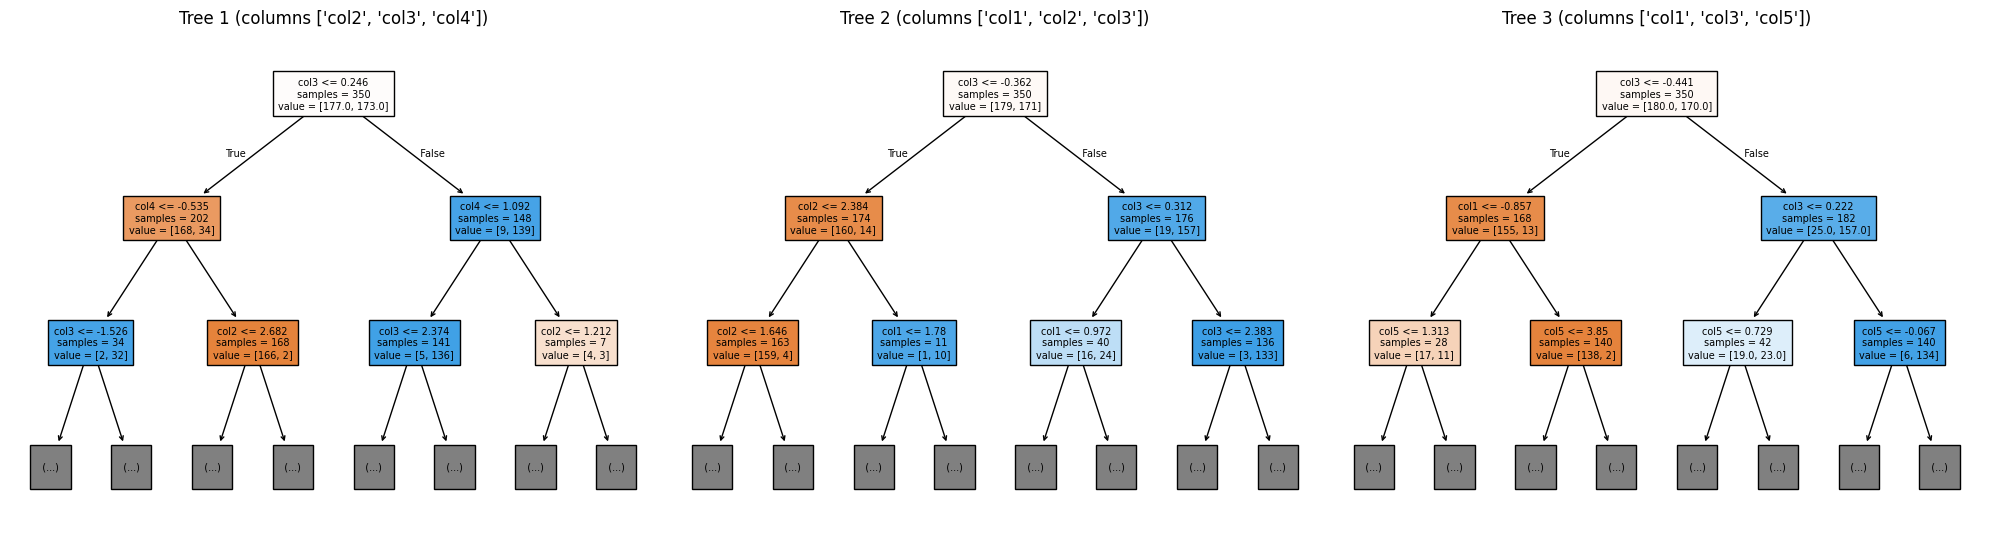

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for k, (ax, (clf, used)) in enumerate(zip(axes, trees)):
    plot_tree(clf, max_depth=2, feature_names=used, filled=True, impurity=False, fontsize=7, ax=ax)
    ax.set_title(f"Tree {k + 1} (columns {used})", fontsize=12)
plt.tight_layout()
plt.show()

Three different trees, each built from different rows and different columns (only the top levels are drawn).

Now let them vote on new rows. Each tree must be given **its own columns** of a row. To see a real vote, we
pick a test row on which the three trees do not agree.

> ✍️ **Core code: learn this.** Predict one query row and take the majority vote.

In [9]:
test_df = pd.DataFrame(X_test, columns=cols)

def votes_of(rows):
    # every tree gets ONLY its own columns of the row(s)
    return np.array([clf.predict(rows[used]) for clf, used in trees])

all3 = votes_of(test_df)                                  # shape (3 trees, n_test rows)
agree = all3.min(axis=0) == all3.max(axis=0)
i = int(np.argmax(~agree))                                # first test row where the trees do NOT agree
query = test_df.iloc[[i]]
print(query.round(3).to_string(index=False))

votes = votes_of(query)[:, 0]
print("\nVotes of the 3 trees:", votes)
print("Majority vote       :", np.bincount(votes).argmax(), "| true label:", y_test[i])
print(f"\n(The 3 trees agree on {agree.mean():.0%} of the test rows; this is one where they do not.)")

 col1  col2  col3   col4  col5
2.487 2.891 0.154 -0.196 -0.43

Votes of the 3 trees: [1 0 0]
Majority vote       : 0 | true label: 0

(The 3 trees agree on 81% of the test rows; this is one where they do not.)


> 🔧 **Fixed from the original version:** the old code fed the *same two numbers* to every tree, even though
> each tree had been trained on *different* columns. Each tree must receive the values of the columns it was
> trained on, as done above with `query[used]`.

### From 3 trees to 100
Same recipe in a loop, then vote on the whole test set:

> ✍️ **Core code: learn this.** A hand-made forest of 100 trees.

In [10]:
hand_forest = []
for seed in range(100):
    d = combined_sampling(train_df, 1.0, 0.6, seed=seed)
    clf = DecisionTreeClassifier(random_state=seed).fit(d.iloc[:, :-1], d['target'])
    hand_forest.append((clf, list(d.columns[:-1])))

all_votes = np.array([clf.predict(test_df[used]) for clf, used in hand_forest])   # shape (100 trees, n_test)
hand_pred = (all_votes.mean(axis=0) > 0.5).astype(int)                             # majority vote

single = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)
sk_rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
print("Single decision tree         :", round(single.score(X_test, y_test), 3))
print("Hand-made forest (100 trees) :", round((hand_pred == y_test).mean(), 3))
print("sklearn RandomForest (100)   :", round(sk_rf.score(X_test, y_test), 3))

Single decision tree         : 0.907
Hand-made forest (100 trees) : 0.967
sklearn RandomForest (100)   : 0.98


- The hand-made forest (0.967) clearly beats a single tree (0.907): voting works even with our simple recipe.
- scikit-learn's forest is a little better still (0.980). Its trees re-draw the columns at **every split**, so each
  tree can use all 5 columns, while each of our hand-made trees is stuck with 3 of them.

## 4. Bagging vs random forest: accuracy and diversity

An ensemble works when its trees are **good** *and* **different**. We measure both on the test set:
- **Strength:** the average accuracy of a single tree inside the ensemble.
- **Diversity:** how often two trees disagree, averaged over all pairs of trees.

And the overall accuracy with 5-fold cross-validation (more reliable than one split).

> ✍️ **Core code: learn this.** Four models, 100 trees each (except the single tree).

In [11]:
models = {
    'Single tree':                  DecisionTreeClassifier(random_state=0),
    'Bagging (all 5 columns)':      BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                                                      random_state=0),
    'Bagging (2 columns per tree)': BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                                                      max_features=2, random_state=0),
    'Random forest (2 per split)':  RandomForestClassifier(n_estimators=100, max_features=2, random_state=0),
}

def tree_votes(model, X):
    # predictions of every tree (bagging trees need their own columns)
    feats = getattr(model, 'estimators_features_', [slice(None)] * len(model.estimators_))
    return np.array([t.predict(X[:, f]) for t, f in zip(model.estimators_, feats)])

rows = []
for name, model in models.items():
    cv = cross_val_score(model, X, y, cv=5).mean()
    model.fit(X_train, y_train)
    row = {'model': name, 'CV accuracy': cv, 'test accuracy': model.score(X_test, y_test)}
    if name != 'Single tree':
        P = tree_votes(model, X_test)
        row['avg single-tree accuracy'] = (P == y_test).mean()
        row['tree disagreement'] = np.mean([(P[i] != P[j]).mean() for i in range(100) for j in range(i + 1, 100)])
    rows.append(row)

results = pd.DataFrame(rows).set_index('model').round(3)
results

,CV accuracy,test accuracy,avg single-tree accuracy,tree disagreement
model,,,,
Single tree,0.960,0.907,NaN,NaN
Bagging (all 5 columns),0.974,0.953,0.932,0.070
Bagging (2 columns per tree),0.970,0.973,0.763,0.331
Random forest (2 per split),0.980,0.980,0.918,0.113


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

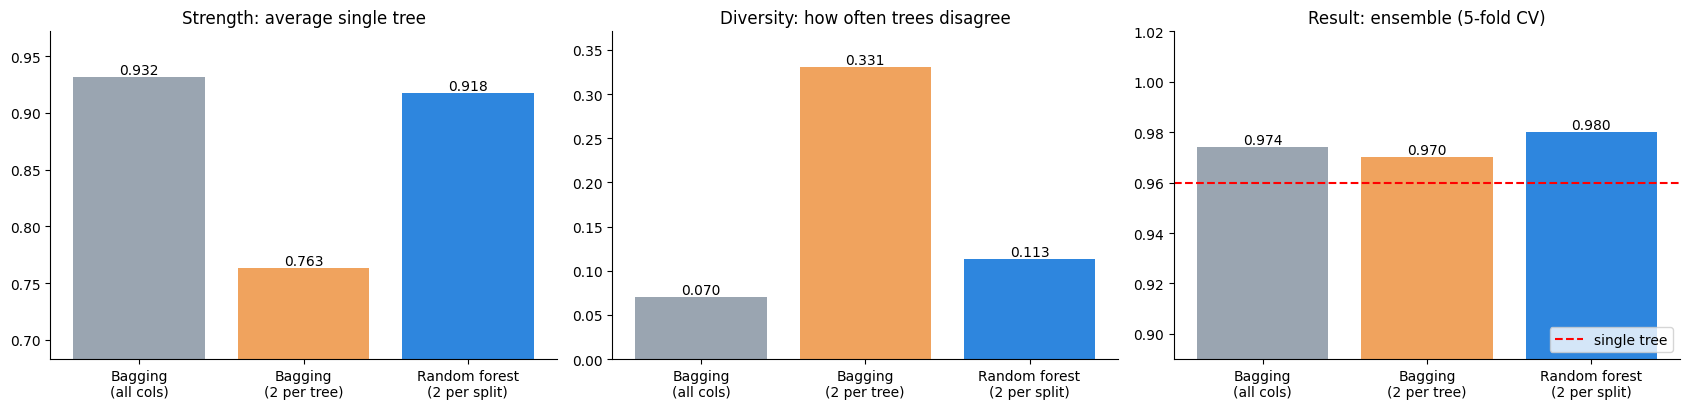

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
r = results.iloc[1:]
short = ['Bagging\n(all cols)', 'Bagging\n(2 per tree)', 'Random forest\n(2 per split)']
for ax, col, title in zip(axes, ['avg single-tree accuracy', 'tree disagreement', 'CV accuracy'],
                          ['Strength: average single tree', 'Diversity: how often trees disagree',
                           'Result: ensemble (5-fold CV)']):
    bars = ax.bar(short, r[col], color=['#9aa5b1', '#f0a35e', '#2e86de'])
    ax.bar_label(bars, fmt='%.3f')
    ax.set_title(title)
    ax.set_ylim(max(0, r[col].min() - 0.08), r[col].max() + 0.04)
axes[2].axhline(results.loc['Single tree', 'CV accuracy'], color='red', ls='--', label='single tree')
axes[2].legend(loc='lower right')
plt.tight_layout()
plt.show()

**What the numbers say:**
- **Bagging (all columns):** the strongest single trees (0.932) but the **least diverse** (they disagree only 7% of
  the time). They tend to make the same mistakes, so voting fixes less.
- **Bagging (2 columns per tree):** the **most diverse** (33% disagreement), but each tree is much **weaker** (0.763)
  because it never sees the other 3 columns. Too much randomness hurts.
- **Random forest (2 per split):** trees almost as strong as full bagging (0.918) *and* more diverse (11%).
  It gets the best 5-fold CV accuracy: **0.980** vs 0.974 and 0.970 (single tree: 0.960).

> 🔎 **Honest note:** the differences between the three ensembles are small here (about 1 percentage point), and
> on the single test split the order of the two bagging models is reversed (0.953 vs 0.973; one test row = 0.7
> points). That is why we also look at cross-validation. The general lesson holds: **an ensemble needs trees that
> are both strong and different**, and per-split feature sampling is a good way to get both.

---
## Key takeaways
- **Bagging** with `max_features`: the random column subset is chosen **once per tree**.
- **Random forest:** a new random column subset is chosen **at every split**, so each tree can still use all features.
- Recipe of a forest: **bootstrap rows + random columns + one tree per sample + majority vote**.
- An ensemble needs trees that are both **good** (strong) and **different** (diverse); random forest balances the two.

## 🧠 Quick check

<details><summary>1. With <code>max_features=2</code>, how many different features can one bagging tree use? And one random-forest tree?</summary>

A bagging tree: at most 2 (the pair it was given). A random-forest tree: any of the 5, because each node draws a new pair.
</details>

<details><summary>2. Why give each tree a bootstrap sample instead of the full data?</summary>

So that the trees are trained on different data and make different mistakes, which cancel out in the vote.
</details>

<details><summary>3. Why is more diversity not always better?</summary>

Diversity only helps if each tree is still reasonably accurate. Very weak trees that disagree a lot can give a worse vote.
</details>

<details><summary>4. In the hand-made forest, why must we pass <code>query[used]</code> to each tree?</summary>

Each tree was trained on its own subset of columns, so it must receive those same columns, in the same order.
</details>

➡️ **Next:** `04-oob-score.ipynb`: the ~37% of rows each tree never sees, and the free validation score they give.